# N-BaIoT Multi-Class Attack Classification using FT-Transformer and XGBoost

**Target:** predict the exact traffic class — `benign`, `mirai.ack`, `mirai.scan`, `mirai.syn`,
`mirai.udp`, `mirai.udpplain`, `gafgyt.combo`, `gafgyt.junk`, `gafgyt.scan`, `gafgyt.tcp`,
`gafgyt.udp` (11 classes total) — across all 9 IoT devices.

**Pipeline**
1. Mount Google Drive, download the dataset from Kaggle
2. Load & label every device's benign + Mirai + Gafgyt traffic files
3. Preprocess (clean, encode labels, scale) and split train/val/test
4. Train a Transformer encoder (FT-Transformer style) as an 11-class classifier on the 115 features
5. Extract `[CLS]` embeddings from the trained Transformer
6. Concatenate embeddings with the original 115 features
7. Train an XGBoost multiclass classifier on the combined feature set
8. Evaluate XGBoost models trained on the Transformer embeddings and the original features


In [ ]:
import os
import glob
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)

import xgboost as xgb
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


Using device: cuda


## 1. Mount Drive & Set Up Project Directories

In [ ]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

# Project root
base_path = "/content/drive/MyDrive/Eng Samah's Research path"
project_path = os.path.join(base_path, "FT_Transformer_NBaIoT")

# Organized subfolders
models_dir = os.path.join(project_path, "models")
embeddings_dir = os.path.join(project_path, "embeddings")
labels_dir = os.path.join(project_path, "labels")
history_dir = os.path.join(project_path, "history")

for folder in [project_path, models_dir, embeddings_dir, labels_dir, history_dir]:
    os.makedirs(folder, exist_ok=True)

print(f"Project directory: {project_path}")

# Save paths
model_save_path = os.path.join(models_dir, "best_fttransformer_model.pth")

train_embeddings_path = os.path.join(embeddings_dir, "train_embeddings.npy")
val_embeddings_path = os.path.join(embeddings_dir, "val_embeddings.npy")
test_embeddings_path = os.path.join(embeddings_dir, "test_embeddings.npy")

y_train_save_path = os.path.join(labels_dir, "y_train.npy")
y_val_save_path = os.path.join(labels_dir, "y_val.npy")
y_test_save_path = os.path.join(labels_dir, "y_test.npy")

training_history_path = os.path.join(history_dir, "training_history.npy")

label_encoder_path = os.path.join(labels_dir, "label_encoder.pkl")
scaler_path = os.path.join(models_dir, "scaler.pkl")
xgb_combined_path = os.path.join(models_dir, "xgb_combined.json")
xgb_baseline_path = os.path.join(models_dir, "xgb_baseline.json")


Mounted at /content/drive
Project directory: /content/drive/MyDrive/Eng Samah's Research path/FT_Transformer_NBaIoT


## 2. Dataset Download Utility (Kaggle / Direct URL)

In [ ]:
from pathlib import Path
import requests
import zipfile
import opendatasets as od

def data_downloading(Data_URL: str):
    """
    Download and extract a ZIP dataset from Kaggle or a direct URL.
    """

    # Identify the website source
    Dataset_website = Data_URL.split('/')[2]

    # Define local storage paths
    data_path = Path("data/")
    data_path.mkdir(parents=True, exist_ok=True)

    File_Name = Data_URL.split('/')[-1]
    File_Without_Extension = File_Name.split('.')[0]
    zip_file_path = data_path / File_Name
    extract_path = data_path / File_Without_Extension

    # If it's a Kaggle dataset
    if 'kaggle.com' in Dataset_website:
        print("Detected Kaggle URL - downloading with opendatasets...")
        od.download(Data_URL, data_dir=str(data_path))
        print("Download complete.")
        return data_path, File_Without_Extension

    # Otherwise: generic download from direct URL
    if extract_path.is_dir():
        print(f"The dataset {extract_path} already exists, skipping download.")
    else:
        print(f"Downloading dataset from {Dataset_website}...")
        response = requests.get(Data_URL)
        with open(zip_file_path, 'wb') as f:
            f.write(response.content)
        print("Download complete. Extracting...")

        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            zip_ref.extractall(extract_path)
        print("Extraction complete.")

        # Remove the ZIP file
        try:
            os.remove(zip_file_path)
        except FileNotFoundError:
            pass

    return extract_path, File_Without_Extension


In [ ]:
data_downloading('https://www.kaggle.com/datasets/mkashifn/nbaiot-dataset/data')


Detected Kaggle URL - downloading with opendatasets...
Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: samahezz
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/mkashifn/nbaiot-dataset


100%|██████████| 1.75G/1.75G [00:45<00:00, 41.5MB/s]



Download complete.


(PosixPath('data'), 'data')

## 3. Build the Full File List (All 9 Devices, Benign + Mirai + Gafgyt)

Each device contributes:
- `{device}.benign.csv`
- `{device}.gafgyt.{combo,junk,scan,tcp,udp}.csv`
- `{device}.mirai.{ack,scan,syn,udp,udpplain}.csv` (skipped for devices 3 and 7, which have no Mirai data)


In [ ]:
DATA_DIR = Path("/content/data/nbaiot-dataset")

DEVICES = list(range(1, 10))
MIRAI_ATTACKS = ["ack", "scan", "syn", "udp", "udpplain"]
GAFGYT_ATTACKS = ["combo", "junk", "scan", "tcp", "udp"]
DEVICES_WITHOUT_MIRAI = {3, 7}  # Ennio_Doorbell, Samsung_SNH_1011_N_Webcam

def build_file_list():
    files = []
    for device in DEVICES:
        files.append(f"{device}.benign.csv")
        for atk in GAFGYT_ATTACKS:
            files.append(f"{device}.gafgyt.{atk}.csv")
        if device not in DEVICES_WITHOUT_MIRAI:
            for atk in MIRAI_ATTACKS:
                files.append(f"{device}.mirai.{atk}.csv")
    return files

files = build_file_list()
print(f"Expecting {len(files)} files across {len(DEVICES)} devices")


Expecting 89 files across 9 devices


## 4. Load & Label All Files

In [ ]:
def get_label_and_device(filename):
    """
    '1.benign.csv'      -> label='benign',      device=1
    '1.mirai.ack.csv'   -> label='mirai.ack',    device=1
    '1.gafgyt.combo.csv'-> label='gafgyt.combo', device=1
    """
    stem = filename.replace(".csv", "")
    parts = stem.split(".")
    device = int(parts[0])
    if parts[1] == "benign":
        label = "benign"
    else:
        label = f"{parts[1]}.{parts[2]}"
    return label, device


def load_and_label(files, data_dir):
    frames = []
    for file in files:
        file_path = data_dir / file
        if not file_path.exists():
            print(f"Skipping missing file: {file}")
            continue

        label, device = get_label_and_device(file)

        df = pd.read_csv(file_path)
        df["attack"] = label
        df["device"] = device
        frames.append(df)

    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


data = load_and_label(files, DATA_DIR)
print("\nCombined dataset shape:", data.shape)

attack_counts = data["attack"].value_counts().sort_values(ascending=False)
print(attack_counts)



Combined dataset shape: (7062606, 117)
attack
mirai.udp         1229999
gafgyt.udp         946366
gafgyt.tcp         859850
mirai.syn          733299
mirai.ack          643821
benign             555932
mirai.scan         537979
mirai.udpplain     523304
gafgyt.combo       515156
gafgyt.junk        261789
gafgyt.scan        255111
Name: count, dtype: int64


In [ ]:
data.head()


,MI_dir_L5_weight,MI_dir_L5_mean,MI_dir_L5_variance,MI_dir_L3_weight,MI_dir_L3_mean,MI_dir_L3_variance,MI_dir_L1_weight,MI_dir_L1_mean,MI_dir_L1_variance,MI_dir_L0.1_weight,...,HpHp_L0.1_pcc,HpHp_L0.01_weight,HpHp_L0.01_mean,HpHp_L0.01_std,HpHp_L0.01_magnitude,HpHp_L0.01_radius,HpHp_L0.01_covariance,HpHp_L0.01_pcc,attack,device
0,1.000000,60.000000,0.000000,1.000000,60.000000,0.000000,1.000000,60.000000,0.000000,1.000000,...,0.0,1.000000,60.000000,0.000000,60.000000,0.000000,0.0,0.0,benign,1
1,1.000000,354.000000,0.000000,1.000000,354.000000,0.000000,1.000000,354.000000,0.000000,1.000000,...,0.0,5.319895,344.262695,4.710446,344.262695,22.188299,0.0,0.0,benign,1
2,1.857879,360.458980,35.789338,1.912127,360.275733,35.923972,1.969807,360.091968,35.991542,1.996939,...,0.0,6.318264,347.703087,9.034660,347.703087,81.625077,0.0,0.0,benign,1
3,1.000000,337.000000,0.000000,1.000000,337.000000,0.000000,1.000000,337.000000,0.000000,1.000000,...,0.0,1.000000,337.000000,0.000000,337.000000,0.000000,0.0,0.0,benign,1
4,1.680223,172.140917,18487.448750,1.793580,182.560279,18928.175300,1.925828,193.165753,19153.795810,1.992323,...,0.0,1.000000,60.000000,0.000000,60.000000,0.000000,0.0,0.0,benign,1


## 5. Dataset Sampling

In [ ]:
SAMPLE_SIZE_PER_CLASS = None

if SAMPLE_SIZE_PER_CLASS is not None:
    data = (
        data.groupby("attack", group_keys=False)
        .apply(lambda x: x.sample(n=min(len(x), SAMPLE_SIZE_PER_CLASS), random_state=SEED))
        .reset_index(drop=True)
    )
    print("Subsampled dataset shape:", data.shape)

print(data["attack"].value_counts())


attack
mirai.udp         1229999
gafgyt.udp         946366
gafgyt.tcp         859850
mirai.syn          733299
mirai.ack          643821
benign             555932
mirai.scan         537979
mirai.udpplain     523304
gafgyt.combo       515156
gafgyt.junk        261789
gafgyt.scan        255111
Name: count, dtype: int64


## 6. Preprocessing & Label Encoding

In [ ]:
FEATURE_COLS = [c for c in data.columns if c not in ["attack", "device"]]
print(f"Number of raw numerical features: {len(FEATURE_COLS)}")

# Drop rows with missing values in feature columns and exact duplicates
data = data.dropna(subset=FEATURE_COLS).reset_index(drop=True)
data = data.drop_duplicates().reset_index(drop=True)

label_encoder = LabelEncoder()
data["label"] = label_encoder.fit_transform(data["attack"])

CLASS_NAMES = label_encoder.classes_
N_CLASSES = len(CLASS_NAMES)
print(f"Number of classes: {N_CLASSES}")
print(dict(enumerate(CLASS_NAMES)))

X = data[FEATURE_COLS].values.astype(np.float32)
y = data["label"].values.astype(np.int64)

print("X shape:", X.shape, "y shape:", y.shape)

joblib.dump(label_encoder, label_encoder_path)
print(f"Label encoder saved to {label_encoder_path}")


Number of raw numerical features: 115
Number of classes: 11
{0: 'benign', 1: 'gafgyt.combo', 2: 'gafgyt.junk', 3: 'gafgyt.scan', 4: 'gafgyt.tcp', 5: 'gafgyt.udp', 6: 'mirai.ack', 7: 'mirai.scan', 8: 'mirai.syn', 9: 'mirai.udp', 10: 'mirai.udpplain'}
X shape: (6904827, 115) y shape: (6904827,)
Label encoder saved to /content/drive/MyDrive/Eng Samah's Research path/FT_Transformer_NBaIoT/labels/label_encoder.pkl


## 7. Train / Validation / Test Split

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

# Feature scaling - fit ONLY on training data to avoid leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

N_FEATURES = X_train_scaled.shape[1]

joblib.dump(scaler, scaler_path)
print(f"Scaler saved to {scaler_path}")


Train: (4833378, 115) Val: (1035724, 115) Test: (1035725, 115)
Scaler saved to /content/drive/MyDrive/Eng Samah's Research path/FT_Transformer_NBaIoT/models/scaler.pkl


## 8. PyTorch Dataset & DataLoader

In [ ]:
class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


BATCH_SIZE = 512

train_ds = TabularDataset(X_train_scaled, y_train)
val_ds = TabularDataset(X_val_scaled, y_val)
test_ds = TabularDataset(X_test_scaled, y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)


## 9. Transformer Model (FT-Transformer style)

In [ ]:
class FeatureTokenizer(nn.Module):
    """
    Converts a vector of N scalar features into N token embeddings of size d_model.
    Each feature gets its own learned weight & bias (per-feature linear projection),
    following the FT-Transformer approach for tabular data.
    """
    def __init__(self, n_features, d_model):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(n_features, d_model) * 0.02)
        self.bias = nn.Parameter(torch.zeros(n_features, d_model))

    def forward(self, x):
        # x: (batch, n_features) -> (batch, n_features, d_model)
        return x.unsqueeze(-1) * self.weight + self.bias


class TabularTransformer(nn.Module):
    def __init__(self, n_features, d_model=64, n_heads=4, n_layers=3,
                 d_ff=256, dropout=0.1, n_classes=11):
        super().__init__()
        self.tokenizer = FeatureTokenizer(n_features, d_model)
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)
        self.pos_embedding = nn.Parameter(torch.randn(1, n_features + 1, d_model) * 0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_ff,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.norm = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(d_model, n_classes)

    def forward(self, x, return_embedding=False):
        batch_size = x.size(0)
        tokens = self.tokenizer(x)                          # (B, N, d_model)
        cls = self.cls_token.expand(batch_size, -1, -1)      # (B, 1, d_model)
        tokens = torch.cat([cls, tokens], dim=1)             # (B, N+1, d_model)
        tokens = tokens + self.pos_embedding

        encoded = self.encoder(tokens)                       # (B, N+1, d_model)
        cls_output = self.norm(encoded[:, 0, :])             # (B, d_model)
        embedding = self.dropout(cls_output)

        logits = self.classifier(embedding)

        if return_embedding:
            return logits, embedding
        return logits


D_MODEL = 64
N_HEADS = 4
N_LAYERS = 3
D_FF = 256
DROPOUT = 0.1

model = TabularTransformer(
    n_features=N_FEATURES,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    n_layers=N_LAYERS,
    d_ff=D_FF,
    dropout=DROPOUT,
    n_classes=N_CLASSES,
).to(DEVICE)

print(model)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {n_params:,}")


TabularTransformer(
  (tokenizer): FeatureTokenizer()
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (classifier): Linear(in_features=64, out_features=11, bias=True)
)

Trainable parameters: 173,003


## 10. Training the Transformer

In [ ]:
def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, all_preds, all_labels = 0.0, [], []

    with torch.set_grad_enabled(is_train):
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)

            if is_train:
                optimizer.zero_grad()

            logits = model(xb)
            loss = criterion(logits, yb)

            if is_train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            total_loss += loss.item() * xb.size(0)
            preds = torch.argmax(logits, dim=1)
            all_preds.append(preds.cpu().numpy())
            all_labels.append(yb.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    acc = accuracy_score(all_labels, all_preds)
    return avg_loss, acc


In [ ]:
EPOCHS = 20
LR = 1e-3
WEIGHT_DECAY = 1e-5
PATIENCE = 4  # early stopping patience (epochs without val-loss improvement)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_loss = float("inf")
patience_counter = 0
best_state = None

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer=None)

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch:02d} | "
          f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
          f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

    if val_loss < best_val_loss - 1e-4:
        best_val_loss = val_loss
        patience_counter = 0
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

# Restore and persist the best model weights (lowest validation loss)
if best_state is not None:
    model.load_state_dict(best_state)
    torch.save(best_state, model_save_path)
    print(f"Best model saved to {model_save_path}")

np.save(training_history_path, history, allow_pickle=True)
print(f"Training history saved to {training_history_path}")


Epoch 01 | train_loss=0.2145 train_acc=0.8651 | val_loss=0.1773 val_acc=0.8806
Epoch 02 | train_loss=0.1808 train_acc=0.8792 | val_loss=0.1753 val_acc=0.8819
Epoch 03 | train_loss=0.1787 train_acc=0.8802 | val_loss=0.1749 val_acc=0.8822
Epoch 04 | train_loss=0.1772 train_acc=0.8811 | val_loss=0.1743 val_acc=0.8832
Epoch 05 | train_loss=0.1768 train_acc=0.8814 | val_loss=0.1744 val_acc=0.8835
Epoch 06 | train_loss=0.1757 train_acc=0.8820 | val_loss=0.1805 val_acc=0.8809
Epoch 07 | train_loss=0.1749 train_acc=0.8825 | val_loss=0.1722 val_acc=0.8842
Epoch 08 | train_loss=0.1741 train_acc=0.8830 | val_loss=0.1716 val_acc=0.8843
Epoch 09 | train_loss=0.1740 train_acc=0.8830 | val_loss=0.1712 val_acc=0.8843
Epoch 10 | train_loss=0.1735 train_acc=0.8834 | val_loss=0.1724 val_acc=0.8841
Epoch 11 | train_loss=0.1729 train_acc=0.8836 | val_loss=0.1819 val_acc=0.8807
Epoch 12 | train_loss=0.1735 train_acc=0.8832 | val_loss=0.1715 val_acc=0.8842
Epoch 13 | train_loss=0.1708 train_acc=0.8844 | val_

## 11. Training Curves

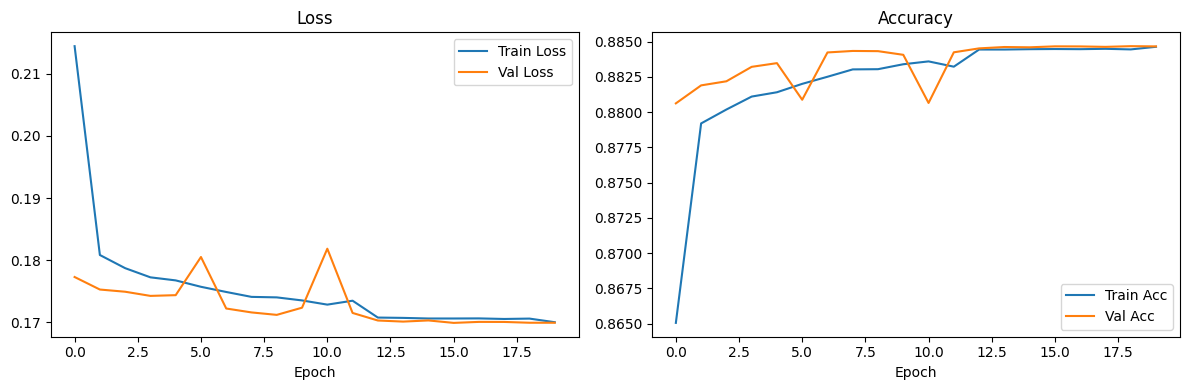

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="Train Loss")
axes[0].plot(history["val_loss"], label="Val Loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history["train_acc"], label="Train Acc")
axes[1].plot(history["val_acc"], label="Val Acc")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()


## 12. Embedding Extraction

In [ ]:
@torch.no_grad()
def extract_embeddings(model, X_scaled, batch_size=1024):
    model.eval()
    embeddings = []
    tensor_X = torch.tensor(X_scaled, dtype=torch.float32)

    for i in range(0, len(tensor_X), batch_size):
        batch = tensor_X[i:i + batch_size].to(DEVICE)
        _, emb = model(batch, return_embedding=True)
        embeddings.append(emb.cpu().numpy())

    return np.concatenate(embeddings, axis=0)


train_embeddings = extract_embeddings(model, X_train_scaled)
val_embeddings = extract_embeddings(model, X_val_scaled)
test_embeddings = extract_embeddings(model, X_test_scaled)

print("Train embeddings shape:", train_embeddings.shape)
print("Val embeddings shape:", val_embeddings.shape)
print("Test embeddings shape:", test_embeddings.shape)

# Persist embeddings and labels to Drive
np.save(train_embeddings_path, train_embeddings)
np.save(val_embeddings_path, val_embeddings)
np.save(test_embeddings_path, test_embeddings)

np.save(y_train_save_path, y_train)
np.save(y_val_save_path, y_val)
np.save(y_test_save_path, y_test)

print("Embeddings and labels saved to Drive.")


Train embeddings shape: (4833378, 64)
Val embeddings shape: (1035724, 64)
Test embeddings shape: (1035725, 64)
Embeddings and labels saved to Drive.


## 13. Concatenate Embeddings with Original Features

In [ ]:
# Combine scaled original 115 features with learned Transformer embeddings
X_train_combined = np.concatenate([X_train_scaled, train_embeddings], axis=1)
X_val_combined = np.concatenate([X_val_scaled, val_embeddings], axis=1)
X_test_combined = np.concatenate([X_test_scaled, test_embeddings], axis=1)

print("Combined train feature shape:", X_train_combined.shape)
print("Combined val feature shape:", X_val_combined.shape)
print("Combined test feature shape:", X_test_combined.shape)


Combined train feature shape: (4833378, 179)
Combined val feature shape: (1035724, 179)
Combined test feature shape: (1035725, 179)


## 14. XGBoost Multiclass Classifier on Combined Features (Original + Embeddings)

In [ ]:
xgb_combined = xgb.XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=N_CLASSES,
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=SEED,
    n_jobs=-1,
)

xgb_combined.fit(
    X_train_combined, y_train,
    eval_set=[(X_val_combined, y_val)],
    verbose=False,
)

xgb_combined.save_model(xgb_combined_path)
print(f"XGBoost (Transformer embeddings + original features) trained and saved to {xgb_combined_path}")


XGBoost (Transformer embeddings + original features) trained and saved to /content/drive/MyDrive/Eng Samah's Research path/FT_Transformer_NBaIoT/models/xgb_combined.json


## 15. Evaluation

In [ ]:
def evaluate_model(model, X_test, y_test, name="Model"):
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)

    acc = accuracy_score(y_test, preds)
    prec_w = precision_score(y_test, preds, average="weighted", zero_division=0)
    rec_w = recall_score(y_test, preds, average="weighted", zero_division=0)
    f1_w = f1_score(y_test, preds, average="weighted", zero_division=0)
    prec_m = precision_score(y_test, preds, average="macro", zero_division=0)
    rec_m = recall_score(y_test, preds, average="macro", zero_division=0)
    f1_m = f1_score(y_test, preds, average="macro", zero_division=0)
    auc = roc_auc_score(y_test, probs, multi_class="ovr", average="macro")

    print(f"--- {name} ---")
    print(f"Accuracy         : {acc:.4f}")
    print(f"Precision (wtd)  : {prec_w:.4f}   Precision (macro): {prec_m:.4f}")
    print(f"Recall (wtd)     : {rec_w:.4f}   Recall (macro)   : {rec_m:.4f}")
    print(f"F1 (wtd)         : {f1_w:.4f}   F1 (macro)       : {f1_m:.4f}")
    print(f"ROC-AUC (macro)  : {auc:.4f}")
    print("\nClassification report:")
    print(classification_report(y_test, preds, target_names=CLASS_NAMES, zero_division=0))

    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    return {
        "accuracy": acc,
        "precision_weighted": prec_w, "recall_weighted": rec_w, "f1_weighted": f1_w,
        "precision_macro": prec_m, "recall_macro": rec_m, "f1_macro": f1_m,
        "roc_auc_macro": auc,
    }


--- XGBoost + Transformer Embeddings ---
Accuracy         : 0.9974
Precision (wtd)  : 0.9974   Precision (macro): 0.9982
Recall (wtd)     : 0.9974   Recall (macro)   : 0.9979
F1 (wtd)         : 0.9974   F1 (macro)       : 0.9980
ROC-AUC (macro)  : 0.9997

Classification report:
                precision    recall  f1-score   support

        benign       1.00      1.00      1.00     77025
  gafgyt.combo       1.00      1.00      1.00     77274
   gafgyt.junk       1.00      1.00      1.00     39268
   gafgyt.scan       1.00      1.00      1.00     38266
    gafgyt.tcp       1.00      0.98      0.99    119294
    gafgyt.udp       0.98      1.00      0.99    134337
     mirai.ack       1.00      1.00      1.00     96573
    mirai.scan       1.00      1.00      1.00     80697
     mirai.syn       1.00      1.00      1.00    109995
     mirai.udp       1.00      1.00      1.00    184500
mirai.udpplain       1.00      1.00      1.00     78496

      accuracy                           1.00  

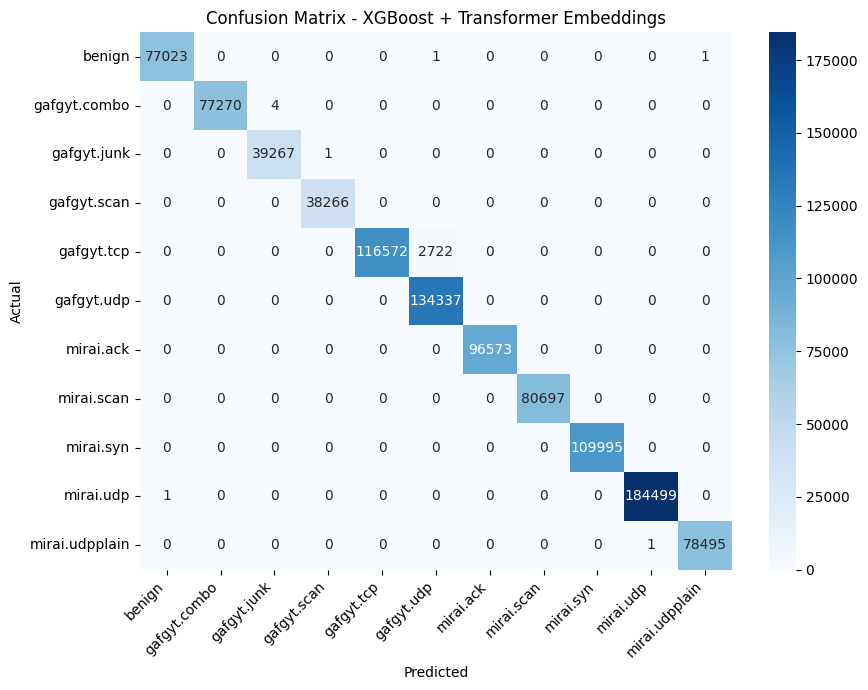

In [ ]:
results_combined = evaluate_model(
    xgb_combined, X_test_combined, y_test, name="XGBoost + Transformer Embeddings"
)


## 16. Feature Importance (Combined Model)

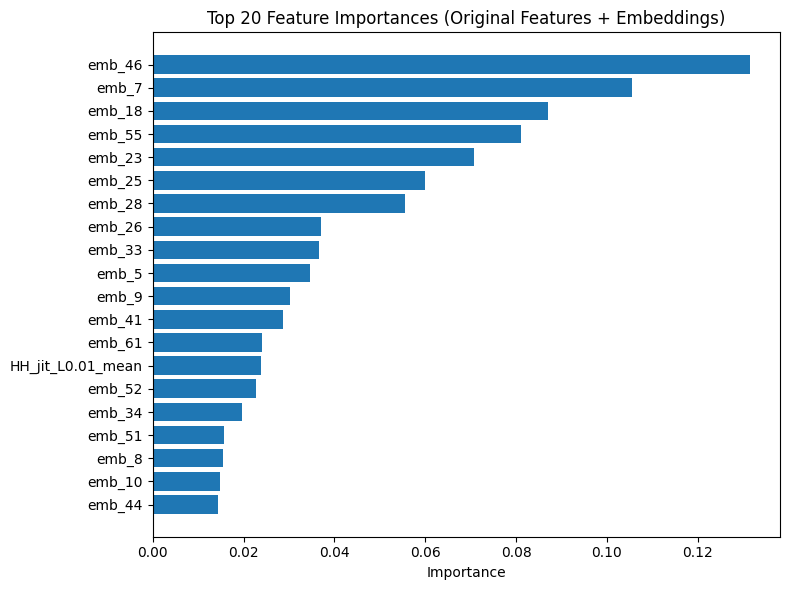

In [ ]:
feature_names = FEATURE_COLS + [f"emb_{i}" for i in range(train_embeddings.shape[1])]

importances = xgb_combined.feature_importances_
top_n = 20
idx = np.argsort(importances)[::-1][:top_n]

plt.figure(figsize=(8, 6))
plt.barh(range(top_n), importances[idx][::-1])
plt.yticks(range(top_n), [feature_names[i] for i in idx][::-1])
plt.xlabel("Importance")
plt.title(f"Top {top_n} Feature Importances (Original Features + Embeddings)")
plt.tight_layout()
plt.show()
